# Preprocessing — Resize, Grayscale, Rotational Augmentation

**Author:** Florian Koenigstorfer

**Goal:** Resize every image to 75×75 with aspect-ratio-preserving padding (LANCZOS), convert to grayscale (mode L), and generate four rotational copies (0°, 90°, 180°, 270°) per source image.

**Data source:** Raw images in /data/Train/ and /data/Test/; writes preprocessed outputs to /data/preprocessed/ and a manifest at /data/preprocessed_df.csv.

## Introduction

Aerial imagery tiles have no canonical orientation — a solar panel viewed from above looks equally valid at any 90° rotation. Generating four rotational copies (0°, 90°, 180°, 270°) per source image therefore augments the training set 4× without introducing unrealistic transformations, helping the downstream classifier generalise across orientations.

## Setup & Imports

In [1]:
%matplotlib inline

import os
import random
import sys

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

sys.path.insert(0, "../src")
from preprocessing import generate_rotations, preprocess_dataset, resize_with_padding

# --- Constants ---
DATA_ROOT            = "../data"
PREPROCESSED_ROOT    = "../data/preprocessed"
PREPROCESSED_DF_PATH = "../data/preprocessed_df.csv"
TARGET_SIZE          = (75, 75)

## Section 1 — Run Preprocessing

In [2]:
def _has_files(directory: str) -> bool:
    """Return True if *directory* exists and contains at least one file."""
    for _, _, files in os.walk(directory):
        if files:
            return True
    return False


if _has_files(PREPROCESSED_ROOT):
    print(f"Preprocessed images already found in '{PREPROCESSED_ROOT}'. Loading existing CSV...")
    preprocessed_df = pd.read_csv(PREPROCESSED_DF_PATH)
    print(f"Loaded {len(preprocessed_df):,} rows from '{PREPROCESSED_DF_PATH}'.")
else:
    print("No preprocessed images found. Running preprocessing pipeline...")
    preprocessed_df = preprocess_dataset(DATA_ROOT, PREPROCESSED_ROOT, TARGET_SIZE)
    preprocessed_df.to_csv(PREPROCESSED_DF_PATH, index=False)
    print(f"Saved {len(preprocessed_df):,} rows to '{PREPROCESSED_DF_PATH}'.")

No preprocessed images found. Running preprocessing pipeline...


Preprocessing images: 100%|██████████| 2506/2506 [00:09<00:00, 269.35it/s]

Saved 10,024 rows to '../data/preprocessed_df.csv'.


## Section 2 — Preprocessing Summary

In [3]:
total_original = preprocessed_df["original_filepath"].nunique()
total_augmented = len(preprocessed_df)
augmentation_multiplier = total_augmented / total_original if total_original > 0 else 0

print(f"Total original images : {total_original:,}")
print(f"Total augmented images: {total_augmented:,}")
print(f"Augmentation multiplier: {augmentation_multiplier:.1f}\u00d7")
print()
print("Counts per split \u00d7 label:")
print(preprocessed_df.groupby(["split", "label"]).size().rename("count").to_string())

Total original images : 2,506
Total augmented images: 10,024
Augmentation multiplier: 4.0×

Counts per split × label:
split  label   
test   negative    1200
       positive     752
train  negative    4800
       positive    3272


## Section 3 — Rotation Visualisation

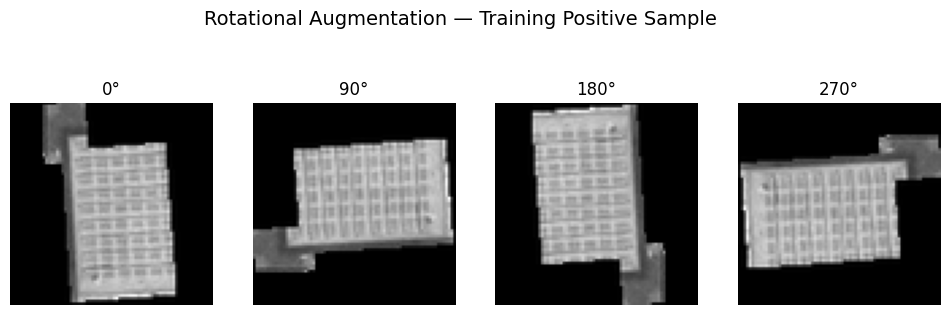

In [4]:
rng = random.Random(42)

train_pos = preprocessed_df[
    (preprocessed_df["split"] == "train") & (preprocessed_df["label"] == "positive")
].reset_index(drop=True)

sample_row = train_pos.iloc[rng.randint(0, len(train_pos) - 1)]
original_path = sample_row["original_filepath"]

image = Image.open(original_path)
padded = resize_with_padding(image, TARGET_SIZE)
gray = padded.convert("L")
rotations = generate_rotations(gray)

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
fig.suptitle("Rotational Augmentation — Training Positive Sample", fontsize=14)

for ax, (angle, rot_img) in zip(axes, rotations.items()):
    ax.imshow(rot_img, cmap="gray")
    ax.set_title(f"{angle}\u00b0")
    ax.axis("off")

plt.show()

## Section 4 — Sanity Checks

In [5]:
rng2 = random.Random(42)

all_paths = preprocessed_df["output_filepath"].tolist()
sample_paths = rng2.sample(all_paths, min(50, len(all_paths)))

failures = []
for p in sample_paths:
    try:
        img = Image.open(p)
        assert img.size == TARGET_SIZE, f"Size mismatch: {img.size}"
        assert img.mode == "L", f"Mode mismatch: {img.mode}"
    except Exception as exc:
        failures.append((p, str(exc)))

print(f"Total files written  : {len(all_paths):,}")
print(f"Sanity-check sample  : {len(sample_paths)} files")
print(f"Failures             : {len(failures)}")

if failures:
    print("\nFailed files:")
    for path, reason in failures:
        print(f"  {path}: {reason}")
else:
    print("All sampled files passed size and mode checks.")

Total files written  : 10,024
Sanity-check sample  : 50 files
Failures             : 0
All sampled files passed size and mode checks.
